# LR with PCA vs without PCA

Accuracy in high-dimensional space: 0.6867
Accuracy after PCA: 0.6867


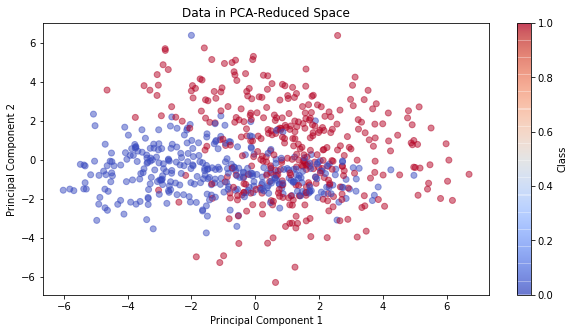

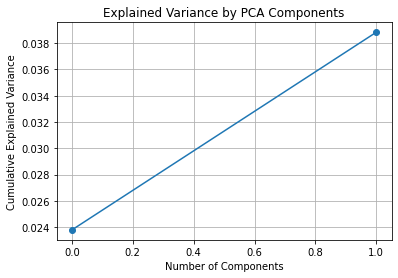

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Generate high-dimensional dataset
X, y = make_classification(n_samples=1000, n_features=250, n_informative=5, n_redundant=10, random_state=42)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression on high-dimensional data
model = LogisticRegression(max_iter=500)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
high_dim_acc = accuracy_score(y_test, y_pred)
print(f'Accuracy in high-dimensional space: {high_dim_acc:.4f}')

# Apply PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Train logistic regression on PCA-reduced data
model_pca = LogisticRegression(max_iter=500)
model_pca.fit(X_train_pca, y_train)
y_pred_pca = model_pca.predict(X_test_pca)
pca_acc = accuracy_score(y_test, y_pred_pca)
print(f'Accuracy after PCA: {pca_acc:.4f}')

# Plot PCA components
plt.figure(figsize=(10, 5))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm', alpha=0.5)
plt.title('Data in PCA-Reduced Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Class')
plt.show()

# Plot explained variance
plt.figure(figsize=(6, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.title('Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid()
plt.show()


In [102]:
pca = PCA(n_components=20)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Train logistic regression on PCA-reduced data
model_pca = LogisticRegression(max_iter=500)
model_pca.fit(X_train_pca, y_train)
y_pred_pca = model_pca.predict(X_test_pca)
pca_acc = accuracy_score(y_test, y_pred_pca)
print(f'Accuracy after PCA: {pca_acc:.4f}')

Accuracy after PCA: 0.7733


In [114]:
pca = PCA(n_components=20)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Train logistic regression on PCA-reduced data
model_pca = LogisticRegression(max_iter=500)
model_pca.fit(X_train_pca, y_train)
y_pred_pca = model_pca.predict(X_test_pca)
pca_acc = accuracy_score(y_test, y_pred_pca)
print(f'Accuracy after PCA: {pca_acc:.4f}')

Accuracy after PCA: 0.7667


# T-SNE vs PCA

In [116]:
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits
import matplotlib.patheffects as PathEffects
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [117]:
mnist = load_digits()
data = pd.DataFrame(mnist.data)
labels = mnist.target

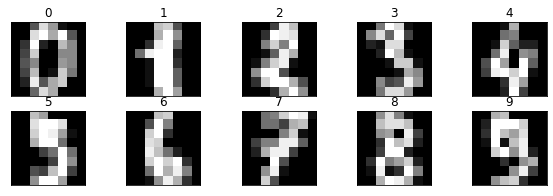

In [118]:
nrows, ncols = 2, 5
plt.figure(figsize=(10,3))
plt.gray()
for i in range(ncols * nrows):
    ax = plt.subplot(nrows, ncols, i + 1)
    ax.matshow(mnist.images[i,...])
    plt.xticks([]); plt.yticks([])
    plt.title(mnist.target[i])
plt.show()

In [119]:
tsne = TSNE(n_components=2, verbose=1, perplexity=40, n_iter=300)
tsne_2 = tsne.fit_transform(data)

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 1797 samples in 0.002s...
[t-SNE] Computed neighbors for 1797 samples in 0.139s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1797
[t-SNE] Computed conditional probabilities for sample 1797 / 1797
[t-SNE] Mean sigma: 8.394135
[t-SNE] KL divergence after 250 iterations with early exaggeration: 61.682190
[t-SNE] KL divergence after 300 iterations: 0.958515


In [120]:
tsne = TSNE(n_components=3, verbose=1, perplexity=40, n_iter=300)
tsne_3 = tsne.fit_transform(data)

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 1797 samples in 0.003s...
[t-SNE] Computed neighbors for 1797 samples in 0.209s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1797
[t-SNE] Computed conditional probabilities for sample 1797 / 1797
[t-SNE] Mean sigma: 8.394135
[t-SNE] KL divergence after 250 iterations with early exaggeration: 61.797478
[t-SNE] KL divergence after 300 iterations: 0.815201


In [121]:
pca = PCA(n_components=2)
pca_2 = pca.fit_transform(data)
pca = PCA(n_components=3)
pca_3 = pca.fit_transform(data)

In [122]:
t21 = tsne_2[:,0]
t22 = tsne_2[:,1] 
t31 = tsne_3[:,0]
t32 = tsne_3[:,1]
t33 = tsne_3[:,2]
p21 = pca_2[:,0]
p22 = pca_2[:,1]
p31 = pca_3[:,0]
p32 = pca_3[:,1]
p33 = pca_3[:,2]

In [123]:
data

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,4.0,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0


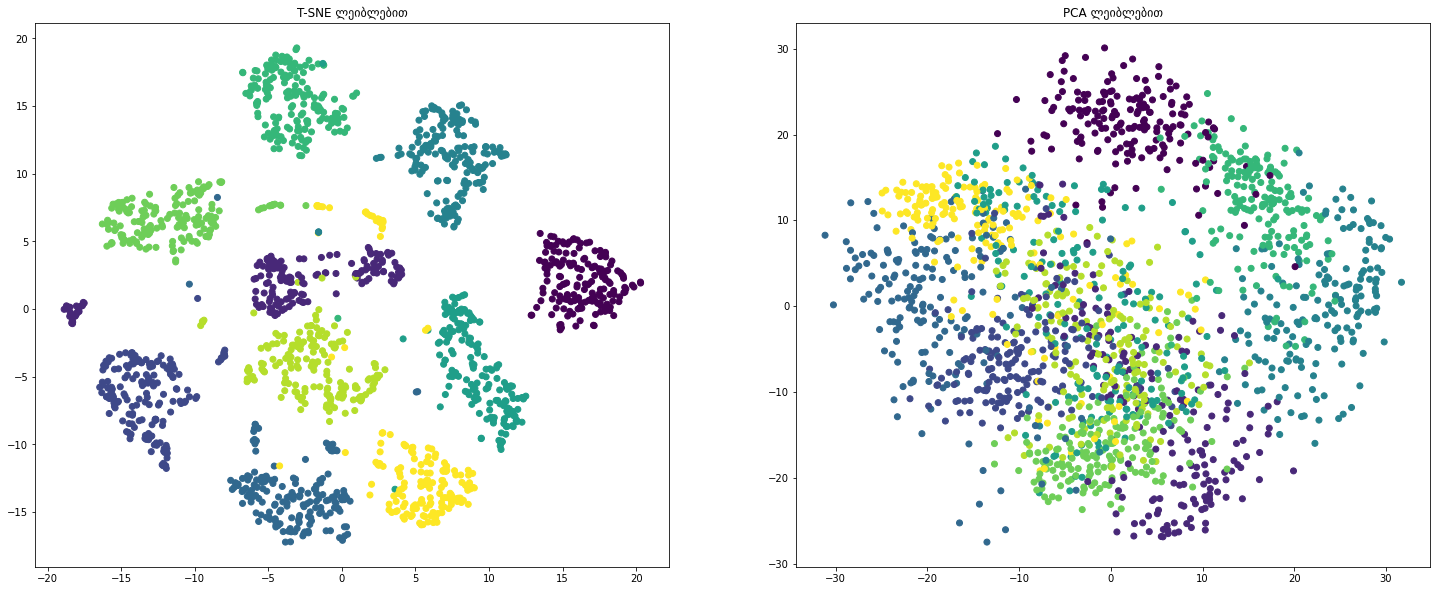

In [124]:
plt.figure(figsize = (25, 10))
ax = plt.subplot(1,2,1)
plt.title('T-SNE ლეიბლებით')
plt.scatter(t21, t22,c = labels,cmap='viridis')
ax = plt.subplot(1,2,2)
plt.title('PCA ლეიბლებით')
plt.scatter(p21, p22,c = labels,cmap='viridis')
plt.show()


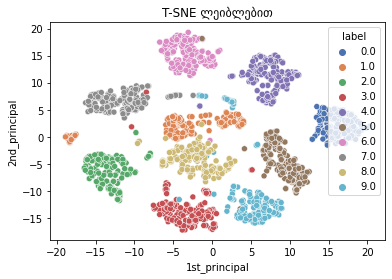

In [125]:
new_coordinates = np.vstack((t21, t22, labels)).T
dataframe = pd.DataFrame(data=new_coordinates, columns=('1st_principal', '2nd_principal', 'label'))

# Convert labels to categorical if they are not numeric
dataframe['label'] = dataframe['label'].astype(str)

sns.scatterplot(data=dataframe, x='1st_principal', y='2nd_principal', hue='label', palette='deep')
plt.title('T-SNE ლეიბლებით')
plt.show()

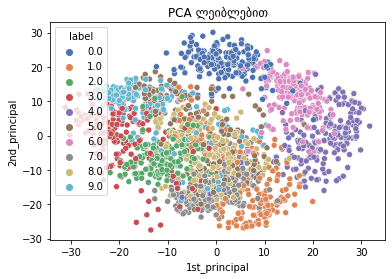

In [126]:
new_coordinates = np.vstack((p21, p22, labels)).T
dataframe = pd.DataFrame(data=new_coordinates, columns=('1st_principal', '2nd_principal', 'label'))

# Convert labels to categorical if they are not numeric
dataframe['label'] = dataframe['label'].astype(str)

sns.scatterplot(data=dataframe, x='1st_principal', y='2nd_principal', hue='label', palette='deep')
plt.title('PCA ლეიბლებით')
plt.show()

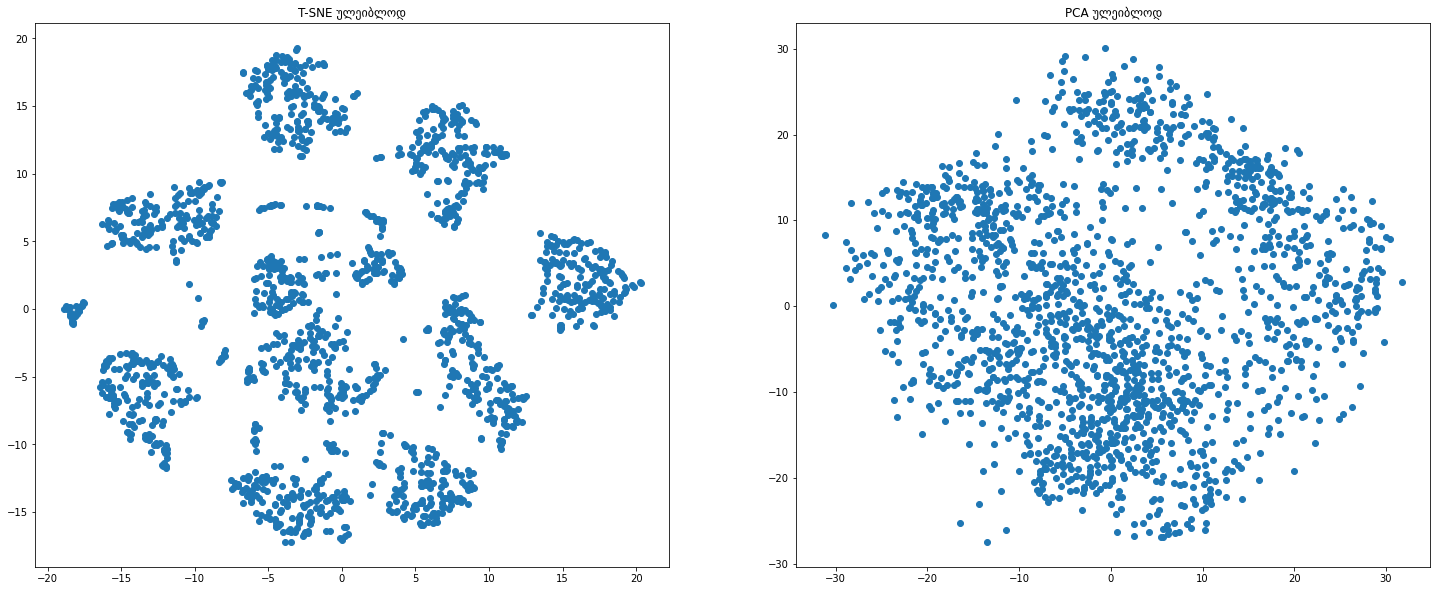

In [127]:
plt.figure(figsize = (25, 10))
ax = plt.subplot(1,2,1)
plt.title('T-SNE ულეიბლოდ')
plt.scatter(t21, t22)
ax = plt.subplot(1,2,2)
plt.title('PCA ულეიბლოდ')
plt.scatter(p21, p22)
plt.show()

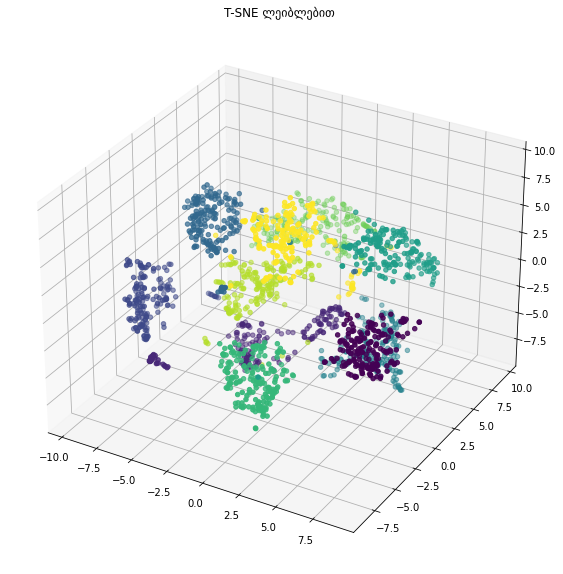

In [128]:
plt.figure(figsize = (25, 10))
ax = plt.axes(projection ="3d")
plt.title('T-SNE ლეიბლებით')
ax.scatter3D(t31, t32, t33, c = labels,cmap='viridis')
plt.show()

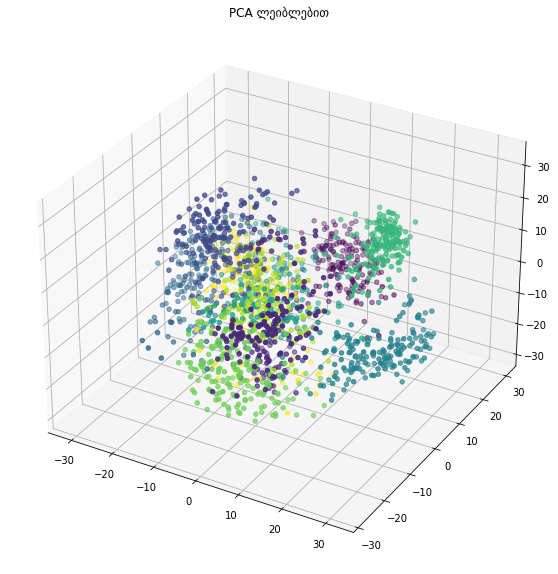

In [129]:
plt.figure(figsize = (25, 10))
ax = plt.axes(projection ="3d")
plt.title('PCA ლეიბლებით')
ax.scatter3D(p31, p32, p33, c = labels,cmap='viridis')
plt.show()

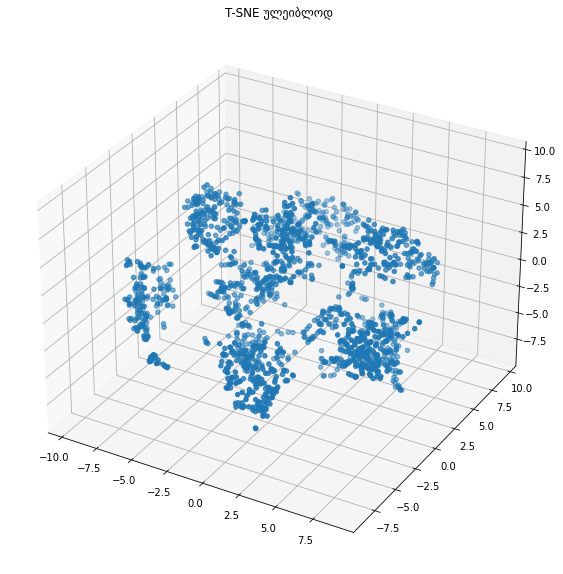

In [130]:
plt.figure(figsize = (25, 10))
ax = plt.axes(projection ="3d")
plt.title('T-SNE ულეიბლოდ')
ax.scatter3D(t31, t32, t33)
plt.show()

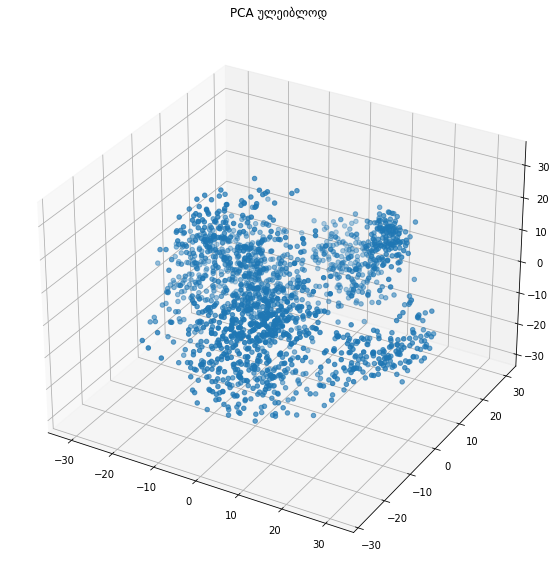

In [131]:
plt.figure(figsize = (25, 10))
ax = plt.axes(projection ="3d")
plt.title('PCA ულეიბლოდ')
ax.scatter3D(p31, p32, p33)
plt.show()

<img src="https://raw.githubusercontent.com/oreillymedia/t-SNE-tutorial/master/images/animation.gif" alt="Italian Trulli">